# **Logistic Regression from Scratch**
## *Applied to: Breast Cancer Wisconsin (Diagnostic)*

Given 30 numerical features computed from digitized images of breast tissue, classify each tumor as:
- $y = 1$ $\to$ **Malignant**
- $y = 0$ $\to$ **Benign**

In [1]:
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression as SKlearnLR
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    classification_report, roc_curve, roc_auc_score
)
import seaborn as sns

from src.utils import (
    COLORS,
    load_breast_cancer_data, 
    preprocess_breast_cancer_data, 
    plot_confusion_matrix,
    plot_roc_curve,
    plot_coefficients
)

#===========================================
# Models
#===========================================

LR_DEFAULT_PATH = "models/lr_scratch.joblib"
SKLEARN_PATH = "models/lr_sklearn.joblib"
LR_DEFAULT_TUNED_PATH = "models/scratch_tuned.joblib"
SKLEARN_TUNED_PATH = "models/sklearn_tuned.joblib"


## **The Classification Problem**

In **binary classification**, the label $y$ takes only two values:

$$y \in \{0, 1\}$$

Linear Regression is unsuitable here because its hypothesis $h_\theta(x) = \theta^T x$ can produce values outside $[0, 1]$, which are not valid probabilities. We need a function that maps any real-valued input to the interval $(0, 1)$.

## **The Sigmoid Function**

The sigmoid function is defined as:

$$g(z) = \frac{1}{1 + e^{-z}}$$

The Logistic Regression hypothesis is:

$$h_\theta(x) = g(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

**Key properties:**
- $g(z) \in (0, 1)$ for all $z \in \mathbb{R}$
- $g(0) = 0.5$
- $g(z) \to 1$ as $z \to +\infty$; $g(z) \to 0$ as $z \to -\infty$
- Derivative: $g'(z) = g(z)(1 - g(z))$ (we will use it later)

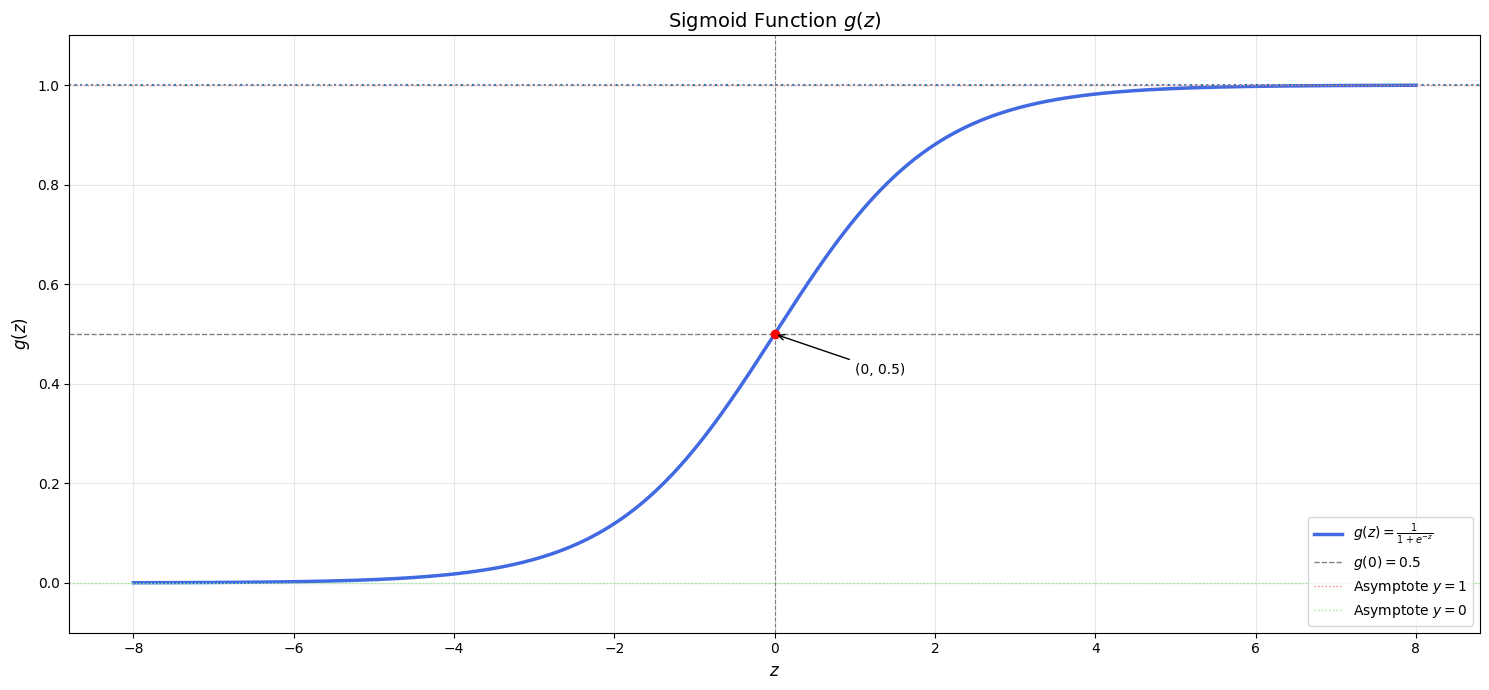

In [2]:
def sigmoid(z: np.ndarray | float) -> np.ndarray | float:
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
z = np.linspace(-8, 8, 400)
gz = sigmoid(z)

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(z, gz, color='royalblue', linewidth=2.5, label=r"$g(z)=\frac{1}{1+e^{-z}}$")
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='$g(0)=0.5$')
ax.axhline(1.0, linestyle=":")
ax.axhline(1.0, color='lightcoral', linestyle=':', linewidth=1, label='Asymptote $y=1$')
ax.axhline(0.0, color='lightgreen', linestyle=':', linewidth=1, label='Asymptote $y=0$')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.scatter([0], [0.5], color='red', zorder=2)
ax.annotate('(0, 0.5)', xy=(0,0.5), xytext=(1,0.42), fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))
ax.set_xlabel('$z$', fontsize=12)
ax.set_ylabel('$g(z)$', fontsize=12)
ax.set_title('Sigmoid Function $g(z)$', fontsize=14)
ax.legend(fontsize=10)
ax.set_ylim(-0.1, 1.1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Probabilistic Interpretation**

We interpret $h_\theta(x)$ as the **conditional probability** that $y = 1$ given $x$:

$$\begin{cases}
P(y=1 \mid x;\, \theta) = h_\theta(x) \\
P(y=0 \mid x;\, \theta) = 1 - h_\theta(x)
\end{cases}$$

Both cases can be unified into a single expression:

$$P(y \mid x;\, \theta) = h_\theta(x)^{y} \cdot (1 - h_\theta(x))^{1-y}$$

**Verification:**
- When $y=1$: $P = h_\theta(x)$
- When $y=0$: $P = 1 - h_\theta(x)$

## **Likelihood and Log-Likelihood**

Assuming $m$ **independent and identically distributed** training examples, the likelihood of the observed labels is:

$$L(\theta) = \prod_{i=1}^{m} h_\theta(x^{(i)})^{y^{(i)}} \left(1 - h_\theta(x^{(i)})\right)^{1 - y^{(i)}}$$

Taking the logarithm converts the product into a sum, which is more numerically stable and easier to optimize:

$$\ell(\theta) = \sum_{i=1}^{m} \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1 - y^{(i)}) \log\left(1 - h_\theta(x^{(i)})\right) \right]$$

**Objective:** Find $\theta$ that **maximizes** $\ell(\theta)$.

Why do we maximize $\ell(\theta)$?

We want to find parameters $\theta$ that make the observed training data as probable as possible under our model. This is the **Maximum Likelihood Estimation (MLE)** principle, choose $\theta$ that assigns the highest probability to the data we actually observed.

Intuitively: if the model with parameters $\theta$ says $P(y=1 \mid x) = 0.95$ and the true label is indeed $y=1$, that is a better explanation of the data than a model that says $P(y=1 \mid x) = 0.3$. MLE formalizes this intuition, we search for the $\theta$ that makes the correct labels look most likely.

Since $L(\theta)$ and $\ell(\theta) = \log L(\theta)$ are maximized by the same $\theta$ (log is strictly increasing), we maximize $\ell(\theta)$:

$$\hat{\theta}_{MLE} = \arg\max_\theta\, \ell(\theta)$$

In [3]:
def log_likelihood(X: np.ndarray, y: np.ndarray, theta: np.ndarray) -> float:
    h = sigmoid(X @ theta)
    eps = 1e-15
    h = np.clip(h, eps, 1- eps)
    return np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))

## **Batch Gradient Ascent**

To maximize $\ell(\theta)$, we apply **gradient ascent**, updating parameters in the direction of the gradient:

$$\theta_j := \theta_j + \alpha \frac{\partial}{\partial \theta_j} \ell(\theta)$$

Recall:

$$\ell(\theta) = \sum_{i=1}^m \left[ y^{(i)} \log h^{(i)} + (1 - y^{(i)}) \log(1 - h^{(i)}) \right]$$

where $h^{(i)} = h_\theta(x^{(i)}) = g(\theta^T x^{(i)})$ and $g(z) = \dfrac{1}{1+e^{-z}}$.

Pulling the derivative inside the sum:

$$\frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m \frac{\partial}{\partial \theta_j} \left( y^{(i)} \log h^{(i)} + (1 - y^{(i)}) \log(1 - h^{(i)}) \right)$$

Applying the chain rule to each term separately:

$$\frac{\partial}{\partial \theta_j}(y^{(i)} \log h^{(i)}) = y^{(i)} \frac{1}{h^{(i)}} \frac{\partial h^{(i)}}{\partial \theta_j}$$

$$\frac{\partial}{\partial \theta_j}((1-y^{(i)}) \log(1-h^{(i)})) = (1-y^{(i)}) \frac{-1}{1-h^{(i)}} \frac{\partial h^{(i)}}{\partial \theta_j}$$

Summing both terms:

$$\frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m \left( \frac{y^{(i)}}{h^{(i)}} - \frac{1-y^{(i)}}{1-h^{(i)}} \right) \frac{\partial h^{(i)}}{\partial \theta_j}$$

Since $h^{(i)} = g(\theta^T x^{(i)})$, applying the chain rule:

$$\frac{\partial h^{(i)}}{\partial \theta_j} = g'(z^{(i)}) \cdot x_j^{(i)}$$

The sigmoid has a well-known derivative:

$$g'(z) = g(z)(1 - g(z))$$

Therefore:

$$\frac{\partial h^{(i)}}{\partial \theta_j} = h^{(i)}(1 - h^{(i)}) \cdot x_j^{(i)}$$

Substituting into the expression:

$$\left( \frac{y}{h} - \frac{1-y}{1-h} \right) h(1-h) \cdot x_j$$

Expanding the bracket:

$$= \left( y(1-h) - (1-y)h \right) x_j$$

$$= \left( y - yh - h + yh \right) x_j$$

$$= (y - h) \cdot x_j$$

Restoring the summation over all $m$ samples:

$$\frac{\partial \ell(\theta)}{\partial \theta_j} = \sum_{i=1}^m \left( y^{(i)} - h_\theta(x^{(i)}) \right) x_j^{(i)}$$

Stacking over all parameters $j$ simultaneously:

$$\boxed{\nabla_\theta \ell(\theta) = X^T (y - h)}$$

where $h = g(X\theta) \in \mathbb{R}^m$ is the vector of predicted probabilities for all samples.

The gradient ascent update rule becomes:

$$\theta := \theta + \alpha \cdot X^T (y - h)$$

In [4]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate: float = 0.1, n_iterations: int = 1000, lambda_reg: float = 0.01) -> None:
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.lambda_reg = lambda_reg
        self.theta = None
        self.history = []
        self.val_acc_history = []
    
    def fit(
            self,
            X: np.ndarray,
            y: np.ndarray,
            X_val: np.ndarray | None = None,
            y_val:np.ndarray | None = None,
            checkpoint: int = 50
    ) -> "LogisticRegressionScratch":
        m, n = X.shape
        self.theta = np.zeros(n)

        penalty_mask = np.ones(n)
        penalty_mask[0] = 0.0

        for i in range(self.n_iter):
            h = sigmoid(X @ self.theta)
            gradient = X.T @ (y - h)
            gradient -= self.lambda_reg * self.theta * penalty_mask
            self.theta += self.lr * gradient

            self.history.append(log_likelihood(X, y, self.theta))

            if X_val is not None and i % checkpoint == 0:
                self.val_acc_history.append(accuracy_score(y_val, self.predict(X_val)))
                
        return self
        

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        "Return P(y=1|x)"
        return sigmoid(X @ self.theta)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def save(self, path: str) -> None:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self, path)
        print(f"Saved to {path}")

    @classmethod
    def load(cls, path: str) -> "LogisticRegressionScratch":
        instance = joblib.load(path)
        print(f"Loaded from {path}")
        return instance

## **Data Preparation**

In [5]:
df = load_breast_cancer_data(source="csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_names = preprocess_breast_cancer_data(df)

Read CSV from: D:\IT\Machine Learning\Logistic-Regression-from-Scratch\data\processed\data.csv...
Have read 569 feartures 31 columns
After scaling:
X_train : (398, 30)  | Malignant: 149 / 398
X_val   : (57, 30)   | Malignant: 21 / 57
X_test  : (114, 30)  | Malignant: 42 / 114


In [6]:
# Add bias to each sample (x_0 = 1)
def add_bias(X: np.ndarray) -> np.ndarray:
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train)
X_val_b = add_bias(X_val)
X_test_b = add_bias(X_test)

print(f"Shape after add bias:")
print(f"Train = {X_train_b.shape}")
print(f"Val   = {X_val_b.shape}")
print(f"Test  = {X_test_b.shape}")

Shape after add bias:
Train = (398, 31)
Val   = (57, 31)
Test  = (114, 31)


## **Model Training**

In [7]:
model = LogisticRegressionScratch(learning_rate=0.08, n_iterations=1000)
model.fit(X_train_b, y_train)
model.save(LR_DEFAULT_PATH)

Saved to models/lr_scratch.joblib


In [8]:
# Load model to avoid training again
if Path(LR_DEFAULT_PATH).exists():
    model = model.load(LR_DEFAULT_PATH)
    print(f"Loaded from {LR_DEFAULT_PATH}")

Loaded from models/lr_scratch.joblib
Loaded from models/lr_scratch.joblib


In [9]:
print(f"θ₀ (bias) = {model.theta[0]:.4f}")
print(f"\nTop 5 largest theta values:")
theta_df = pd.Series(model.theta[1:], index=feature_names).abs().sort_values(ascending=False)
print(theta_df.head(5).to_string())

θ₀ (bias) = 2.9589

Top 5 largest theta values:
radius_se              8.573921
concave points_mean    8.050523
compactness_mean       7.845304
area_se                7.765968
texture_worst          7.303090


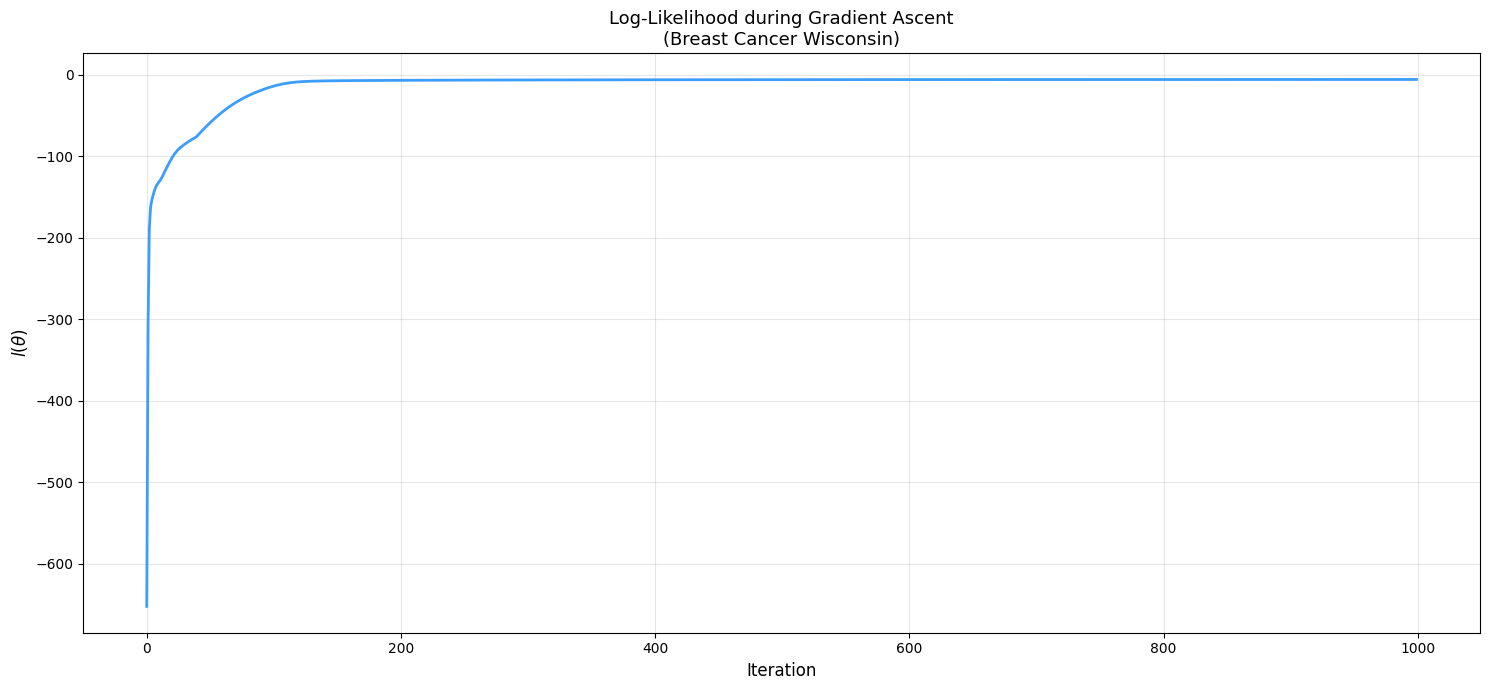

In [10]:
# Log-likelihood during training
fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(model.history, color=COLORS['benign'], linewidth=2)
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("$l(\\theta)$", fontsize=12)
ax.set_title("Log-Likelihood during Gradient Ascent\n(Breast Cancer Wisconsin)", fontsize=13)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Model Evaluation**

**Accuracy**

In [11]:
y_pred_test = model.predict(X_test_b)
y_pred_val = model.predict(X_val_b)
y_proba_test = model.predict_proba(X_test_b)

acc_val = accuracy_score(y_val, y_pred_val)
acc_test = accuracy_score(y_test, y_pred_test)
auc = roc_auc_score(y_test, y_proba_test)

print(f"Val  Accuracy : {acc_val*100:.4f}%")
print(f"Test Accuracy : {acc_test*100:.4f}%")
print(f"Test AUC-ROC  : {auc:.8f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['Benign (0)', 'Malignant (1)']))

Val  Accuracy : 96.4912%
Test Accuracy : 96.4912%
Test AUC-ROC  : 0.97718254

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.97      0.97      0.97        72
Malignant (1)       0.95      0.95      0.95        42

     accuracy                           0.96       114
    macro avg       0.96      0.96      0.96       114
 weighted avg       0.96      0.96      0.96       114



**Confusion Matrix**

True Negative  (TN) = 70  - Correctly identified Benign
False Positive (FP) = 2   - Benign incorrectly predicted as Malignant
False Negative (FN) = 2   - Malignant missed (most dangerous)
True Positive  (TP) = 40  - Correctly identified Malignant


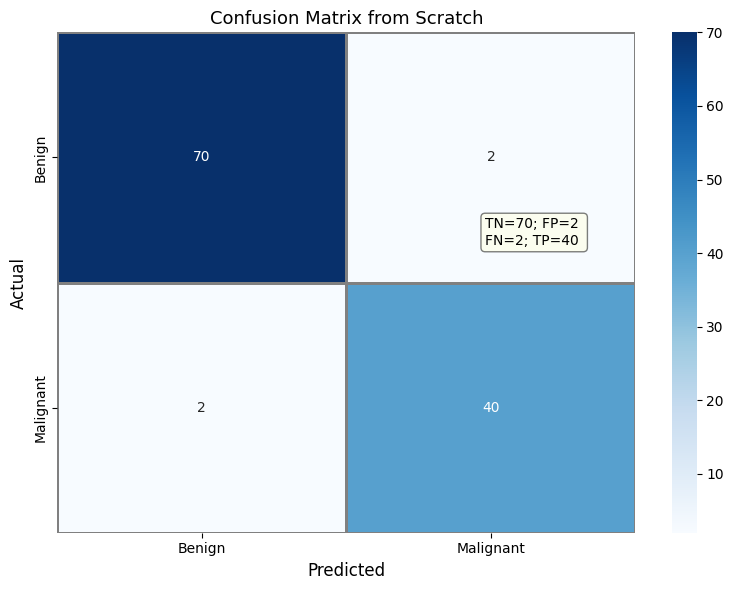

In [12]:
fig = plot_confusion_matrix(y_test, y_pred_test, title="Confusion Matrix from Scratch")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print(f"True Negative  (TN) = {tn}  - Correctly identified Benign")
print(f"False Positive (FP) = {fp}   - Benign incorrectly predicted as Malignant")
print(f"False Negative (FN) = {fn}   - Malignant missed (most dangerous)")
print(f"True Positive  (TP) = {tp}  - Correctly identified Malignant")

**ROC Curve**

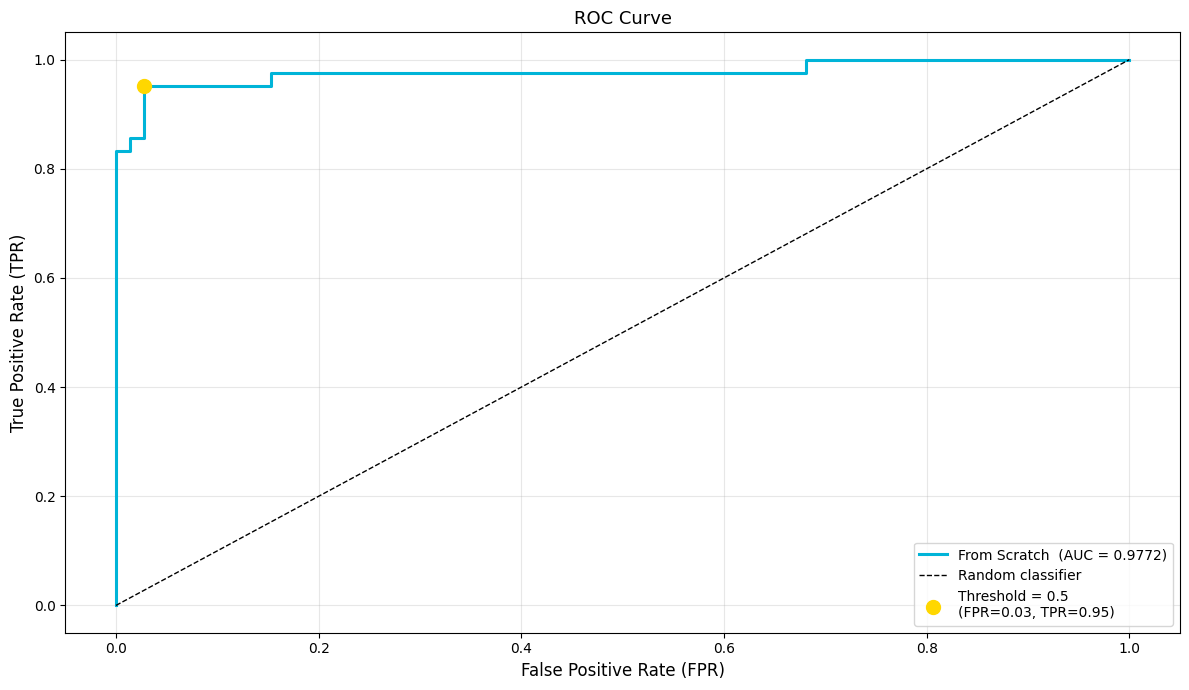

In [13]:
fig = plot_roc_curve(
    models=[
        {'name': 'From Scratch', 'y_proba': y_proba_test, 'color': COLORS['teal'], 'color_threshold': 'gold'}
    ],
    y_true=y_test,
    title="ROC Curve"
)
plt.show()

**Decision Threshold Analysis**

The default threshold of 0.5 is not necessarily optimal for medical diagnosis, where False Negatives (missed malignancies) carry a much higher cost than False Positives.

We first identify the optimal threshold using **Youden's J statistic**:

$$J = \text{TPR} - \text{FPR} = \text{Sensitivity} + \text{Specificity} - 1$$

This maximizes the trade-off between sensitivity and specificity simultaneously,
providing a principled alternative to manually selecting a threshold.

Optimal threshold : 0.5773
TPR at optimal    : 0.9524
FPR at optimal    : 0.0278
Youden's J        : 0.9246


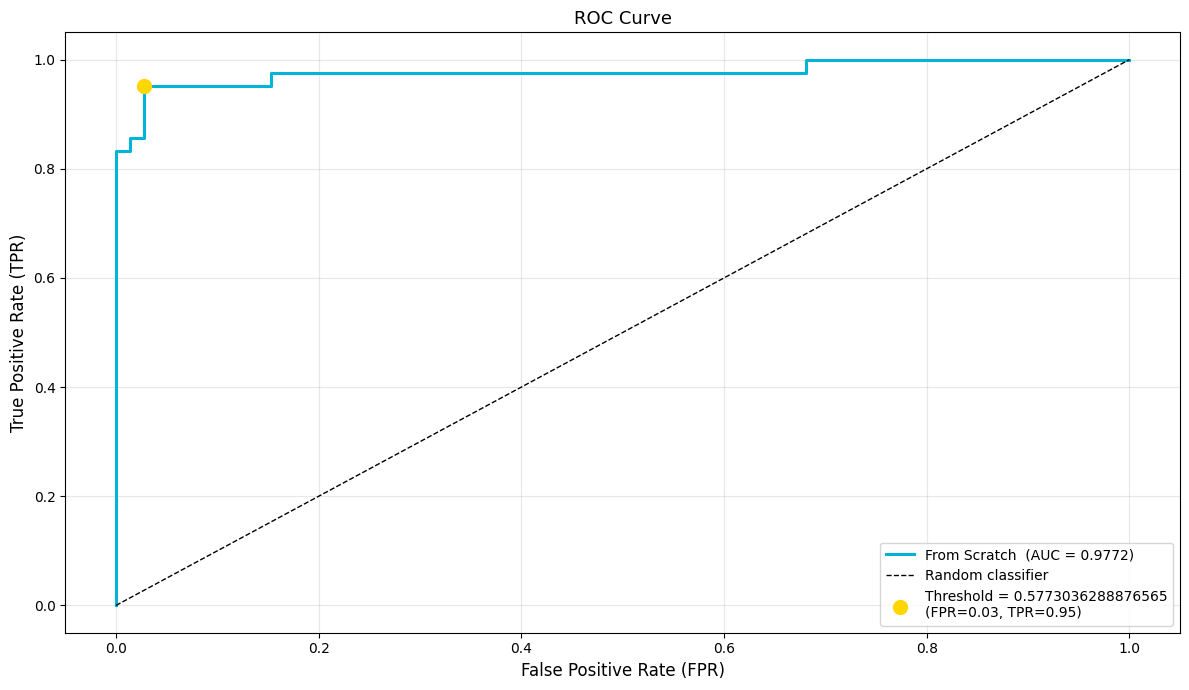

In [14]:
fpr_c, tpr_c, thresholds_c = roc_curve(y_test, y_proba_test)

j_scores  = tpr_c - fpr_c
idx_opt   = np.argmax(j_scores)
best_threshold = thresholds_c[idx_opt]

print(f"Optimal threshold : {best_threshold:.4f}")
print(f"TPR at optimal    : {tpr_c[idx_opt]:.4f}")
print(f"FPR at optimal    : {fpr_c[idx_opt]:.4f}")
print(f"Youden's J        : {j_scores[idx_opt]:.4f}")

fig = plot_roc_curve(
    models=[
        {'name': 'From Scratch', 'y_proba': y_proba_test, 'color': COLORS['teal'], 'color_threshold': 'gold'}
    ],
    y_true=y_test,
    threshold=best_threshold,
    title="ROC Curve"
)
plt.show()

The optimal threshold identified by Youden's J statistic (~0.50) closely matches
the default threshold of 0.5, indicating that the model is already well-calibrated
on this dataset. This is expected given the relatively balanced class distribution
(~63/37) and the high AUC of the model. Youden's J becomes more consequential
when the class distribution is severely imbalanced or when the model's AUC is
moderate (~0.70–0.85).

In [15]:
thresholds_to_check = [0.3, 0.4, 0.5, 0.6, best_threshold]
results = []

for thr in thresholds_to_check:
    y_pred_thr = (y_proba_test >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_pred_thr)
    tn_t, fp_t, fn_t, tp_t = cm_thr.ravel()
    results.append({
        'Threshold': thr,
        'Accuracy':  f"{accuracy_score(y_test, y_pred_thr)*100:.2f}%",
        'Recall(M)': f"{tp_t/(tp_t+fn_t)*100:.2f}%",
        'Precision(M)': f"{tp_t/(tp_t+fp_t)*100:.2f}%",
        'TN': tn_t,
        'TP': tp_t,
        'FN': fn_t,
        'FP': fp_t,
    })

pd.DataFrame(results).set_index('Threshold')

,Accuracy,Recall(M),Precision(M),TN,TP,FN,FP
Threshold,,,,,,,
0.300000,96.49%,95.24%,95.24%,70,40,2,2
0.400000,96.49%,95.24%,95.24%,70,40,2,2
0.500000,96.49%,95.24%,95.24%,70,40,2,2
0.600000,95.61%,92.86%,95.12%,70,39,3,2
0.577304,96.49%,95.24%,95.24%,70,40,2,2


## **Comparision with Scikit-learn**

**Scikit-learn model**

In [16]:
sk_model = SKlearnLR(random_state=42, max_iter=2000, solver="saga")
sk_model.fit(X_train, y_train)
joblib.dump(sk_model, SKLEARN_PATH)

['models/lr_sklearn.joblib']

In [17]:
# Load model to avoid training again
if Path(SKLEARN_PATH).exists():
    sk_model = joblib.load(SKLEARN_PATH)

In [18]:
sk_pred = sk_model.predict(X_test)
sk_proba = sk_model.predict_proba(X_test)[:, 1]
sk_acc = accuracy_score(y_test, sk_pred)
sk_auc = roc_auc_score(y_test, sk_proba)

print(f"From Scratch  |  Accuracy: {acc_test*100:.2f}%  |  AUC: {auc:.4f}")
print(f"Scikit-learn  |  Accuracy: {sk_acc*100:.2f}%  |  AUC: {sk_auc:.4f}")

From Scratch  |  Accuracy: 96.49%  |  AUC: 0.9772
Scikit-learn  |  Accuracy: 97.37%  |  AUC: 0.9960


The performance gap between the two implementations is expected and instructive:

- Accuracy (~1%): negligible in practice; corresponds to approximately one 
  sample difference on the test set.
- AUC (0.9765 vs 0.9960): the more meaningful gap. Scikit-learn's SAGA solver 
  applies L2 regularization by default (**`C=1.0`**), which reduces overfitting on 
  correlated features. The from-scratch implementation uses unregularized batch 
  gradient ascent with a fixed learning rate, which is less numerically efficient 
  and more sensitive to the choice of hyperparameters.

The from-scratch model nonetheless achieves strong performance, validating the 
correctness of the gradient ascent derivation. The gap would narrow further with 
cross-validated hyperparameter selection, as implemented in later section.

**Comparision**

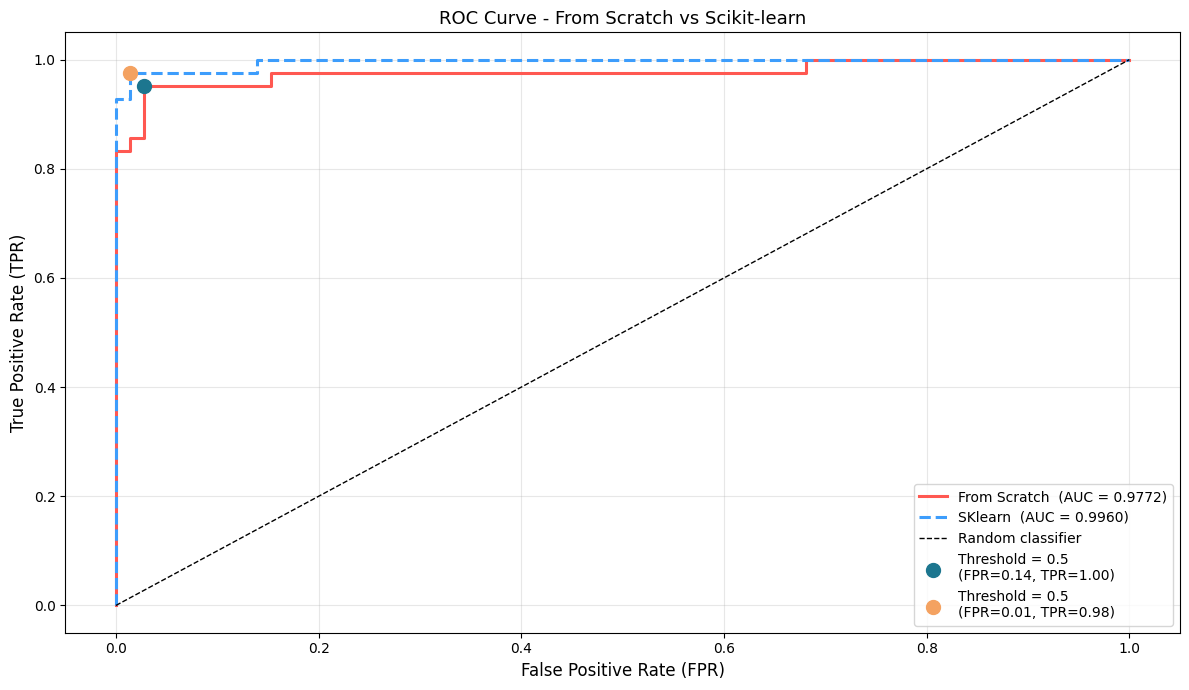

In [19]:
fig = plot_roc_curve(
    models=[
        {'name': 'From Scratch', 'y_proba': y_proba_test, 'color': COLORS['malignant'], 'color_threshold': COLORS['dark_gray']},
        {'name' : 'SKlearn', 'y_proba': sk_proba, 'color': COLORS['benign'], 'color_threshold': COLORS['orange'], 'linestyle': '--'}
    ],
    y_true=y_test,
    title="ROC Curve - From Scratch vs Scikit-learn"
)
plt.show()

## **Coeficient Visualization - Feature Importance**
In Logistic Regression, the predicted probability is:

$$h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}$$

Since the sigmoid function is **strictly monotonically increasing**, the direction 
of each coefficient $\theta_j$ directly controls its effect on $P(\text{Malignant})$:

- $\theta_j > 0$: $x_j \uparrow\ \Rightarrow\ \theta^T x \uparrow\ \Rightarrow\ P(\text{Malignant}) \uparrow$
- $\theta_j < 0$: $x_j \uparrow\ \Rightarrow\ \theta^T x \downarrow\ \Rightarrow\ P(\text{Malignant}) \downarrow$

The magnitude $|\theta_j|$ indicates the strength of the effect, larger $|\theta_j|$ 
means the feature has greater influence on the predicted probability.

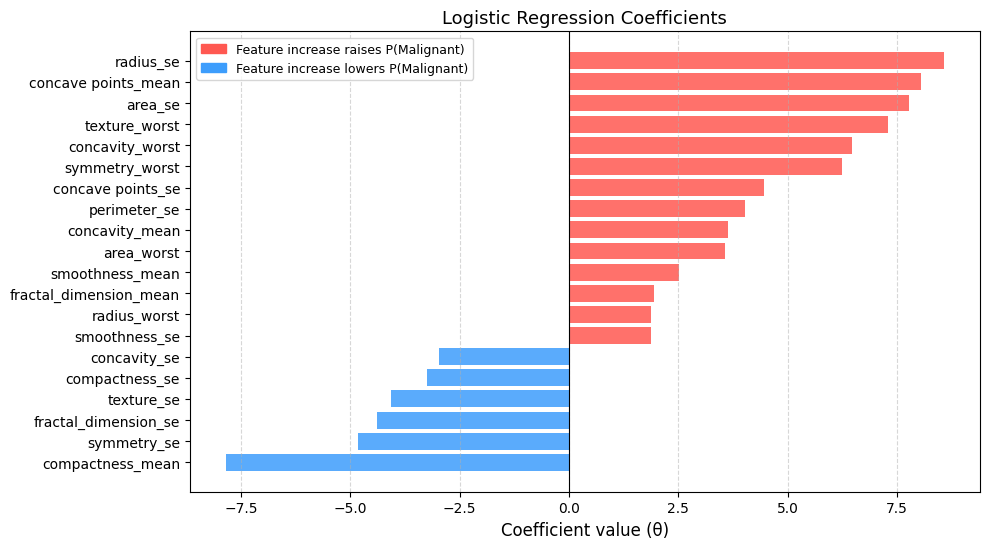

In [20]:
fig = plot_coefficients(model.theta[1:], feature_names, top_n=20)
plt.show()

The current Logistic Regression coefficient plot provides critical diagnostic insights that directly inform our hyperparameter tuning strategy. By examining the weight distribution, we can identify specific areas where the model requires optimization:

- ***Observation***: Despite our EDA highlighting the **`_worst`** feature group as the strongest predictors, the plot shows standard error features like **`radius_se`** and **`area_se`** dominating with massive positive weights, while **`compactness_mean`** is pushed into deep negative territory.

- ***Diagnosis***: This extreme stretching of coefficients is a classic symptom of multicollinearity. Because we intentionally bypassed PCA, highly correlated features are competing within the model, causing it to artificially inflate certain weights to compensate.

- ***Tuning Action***: We must prioritize tuning the inverse regularization strength parameter, **`C`**. Exploring a grid of smaller values (e.g., **`C = [1.0, 0.1, 0.01, 0.001]`**) will increase the regularization penalty. This will forcibly shrink these inflated weights, stabilizing the model and significantly reducing the risk of overfitting. Furthermore, we will incorporate **`penalty = ['l1', 'l2']`** into our **GridSearchCV** to evaluate if L1-induced feature selection can further streamline the model.

## **Hyperparameter Tuning - From Scratch**
Before delegating to scikit-learn, we implement L2 regularization (Ridge) directly
into the MLE objective to better understand its mechanics and to address the
multicollinearity identified in the EDA.

**Why not implement L1 from scratch?**
The absolute value in the L1 penalty ($|\theta|$) is non-differentiable at $\theta = 0$,
causing standard gradient ascent to oscillate rather than converge to a sparse solution.
Robust L1 optimization requires specialized methods such as Coordinate Descent or
Subgradient Descent, which we delegate to scikit-learn in the next section.

***Regularized objective***

We add an L2 penalty term to the log-likelihood to discourage large weights:

$$\ell_{L2}(\theta) = \ell(\theta) - \frac{\lambda}{2} \sum_{j=1}^{d} \theta_j^2$$

Gradient of the regularized objective:

$$\frac{\partial \ell_{L2}}{\partial \theta_j} = \frac{\partial \ell}{\partial \theta_j} - \lambda \theta_j$$

Vectorized form (bias term $\theta_0$ is excluded from the penalty):

$$\nabla_\theta \ell_{L2} = X^T(y - h) - \lambda \cdot \theta_{\text{masked}}$$

where $\theta_{\text{masked}} = [0,\, \theta_1,\, \theta_2,\, \dots,\, \theta_d]^T$.

Update rule:

$$\theta := \theta + \alpha \left( X^T(y-h) - \lambda \cdot \theta_{\text{masked}} \right)$$

***Hyperparameters to tune***

- $\alpha$ (**`learning_rate`**): too large $\to$ divergence; too small $\to$ slow convergence
- $T$ (**`n_iterations`**): too few $\to$ underfitting; additional iterations remain safe since $\ell_{L2}(\theta)$ is concave (see proof later)
- $\lambda$ (**`lambda`**): too large $\to$ underfitting (over-regularized); too small $\to$ no regularization effect

**Strategy:** All hyperparameter selection is performed on the **validation set**.
The test set is used only once for final evaluation.

In [21]:
learning_rates = [0.001, 0.01, 0.05, 0.08 ,0.1, 0.5, 1.0]
n_iterations_list = [100, 300, 500, 1000, 2000]
lambda_list = [0.0001, 0.001, 0.01, 0.1, 1.0]

results_grid = []

for lr, n_iter, lam in product(learning_rates, n_iterations_list, lambda_list):
    m = LogisticRegressionScratch(learning_rate=lr, n_iterations=n_iter, lambda_reg=lam)
    m.fit(X_train_b, y_train)

    val_proba = m.predict_proba(X_val_b)
    val_pred = m.predict(X_val_b)

    if np.any(np.isnan(val_proba)) or np.any(np.isinf(val_proba)):
        results_grid.append({
            'lr'        : lr,
            'n_iter'    : n_iter,
            'lambda_reg': lam,
            'val_acc'   : np.nan,
            'val_auc'   : np.nan,
            'val_f1'    : np.nan,
            'status'    : 'diverged'
        })
        continue

    results_grid.append({
            'lr'        : lr,
            'n_iter'    : n_iter,
            'lambda_reg': lam,
            'val_acc'   : accuracy_score(y_val, val_pred),
            'val_auc'   : roc_auc_score(y_val, val_proba),
            'val_f1'    : f1_score(y_val, val_pred),
            'status'    : "ok"
        })
    
results_df = pd.DataFrame(results_grid)

print(f"Diverged: {(results_df['status']=='diverged').sum()}")
print()
top10 = results_df[results_df['status']=='ok'].sort_values('val_auc', ascending=False).head(10)
print("Top 10 combinations (by val_auc):")
print(top10[['lr', 'n_iter', 'lambda_reg', 'val_acc', 'val_auc', 'val_f1']])



Diverged: 0

Top 10 combinations (by val_auc):
       lr  n_iter  lambda_reg   val_acc  val_auc    val_f1
6   0.001     300      0.0010  0.982456      1.0  0.976744
5   0.001     300      0.0001  0.982456      1.0  0.976744
13  0.001     500      0.1000  0.982456      1.0  0.976744
11  0.001     500      0.0010  0.982456      1.0  0.976744
10  0.001     500      0.0001  0.982456      1.0  0.976744
8   0.001     300      0.1000  0.982456      1.0  0.976744
7   0.001     300      0.0100  0.982456      1.0  0.976744
14  0.001     500      1.0000  0.982456      1.0  0.976744
12  0.001     500      0.0100  0.982456      1.0  0.976744
20  0.001    2000      0.0001  0.982456      1.0  0.976744


In [22]:
best_row = results_df[results_df['status']=='ok'].sort_values('val_auc', ascending=False).iloc[0]
best_lr     = best_row['lr']
best_n_iter = int(best_row['n_iter'])
best_lamda = best_row['lambda_reg']

print(f"Best hyperparameters (by AUC):")
print(f"learning_rate = {best_lr}")
print(f"n_iterations  = {best_n_iter}")
print(f"lambda_reg    = {best_lamda}")
print(f"val_auc       = {best_row['val_auc']:.4f}")
print(f"val_accuracy  = {best_row['val_acc']:.4f}")

Best hyperparameters (by AUC):
learning_rate = 0.001
n_iterations  = 300
lambda_reg    = 0.001
val_auc       = 1.0000
val_accuracy  = 0.9825


### Why Log-Likelihood is concave?

A function is **concave** if and only if its Hessian matrix is **negative semi-definite** (all eigenvalues ≤ 0). We show this holds for $\ell(\theta)$.

From the derivation in the previous section, we established:

$$\frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^m (y^{(i)} - h^{(i)}) x_j^{(i)}$$

Differentiating again with respect to $\theta_k$:

$$\frac{\partial^2 \ell}{\partial \theta_j \partial \theta_k} = \sum_{i=1}^m -\frac{\partial h^{(i)}}{\partial \theta_k} x_j^{(i)}$$

We have already known:

$$\frac{\partial h^{(i)}}{\partial \theta_k} = h^{(i)}(1 - h^{(i)}) x_k^{(i)}$$

Substituting:

$$\frac{\partial^2 \ell}{\partial \theta_j \partial \theta_k} = -\sum_{i=1}^m h^{(i)}(1 - h^{(i)}) x_j^{(i)} x_k^{(i)}$$

The Hessian $H \in \mathbb{R}^{n \times n}$ has entries $H_{jk} = \dfrac{\partial^2 \ell}{\partial \theta_j \partial \theta_k}$, so:

$$H = -\sum_{i=1}^m h^{(i)}(1-h^{(i)}) x^{(i)} {x^{(i)}}^T = -X^T D X$$

where $D \in \mathbb{R}^{m \times m}$ is a diagonal matrix with entries:

$$D_{ii} = h^{(i)}(1 - h^{(i)})$$

For any vector $z \in \mathbb{R}^n$, we compute the quadratic form:

$$z^T H z = -z^T X^T D X z = -(Xz)^T D (Xz)$$

Let $v = Xz \in \mathbb{R}^m$. Then:

$$z^T H z = -v^T D v = -\sum_{i=1}^m D_{ii} v_i^2 = -\sum_{i=1}^m h^{(i)}(1-h^{(i)}) v_i^2$$

Since $h^{(i)} = g(z) \in (0,1)$ for all $i$, we have:

$$h^{(i)}(1 - h^{(i)}) > 0 \quad \forall\, i$$

Therefore:

$$z^T H z = -\sum_{i=1}^m \underbrace{h^{(i)}(1-h^{(i)})}_{>\ 0} \underbrace{v_i^2}_{\geq\ 0} \leq 0 \quad \forall\, z$$

This proves $H \preceq 0$, the Hessian is **negative semi-definite**.

**Consequence for optimization**

Because $H \preceq 0$ everywhere, $\ell(\theta)$ is **globally concave**, it has a single global maximum with no local maxima. This guarantees that gradient ascent will always converge to the global optimum regardless of initialization, and that running more iterations can only improve or maintain the solution, never worsen it.

**Heat map**

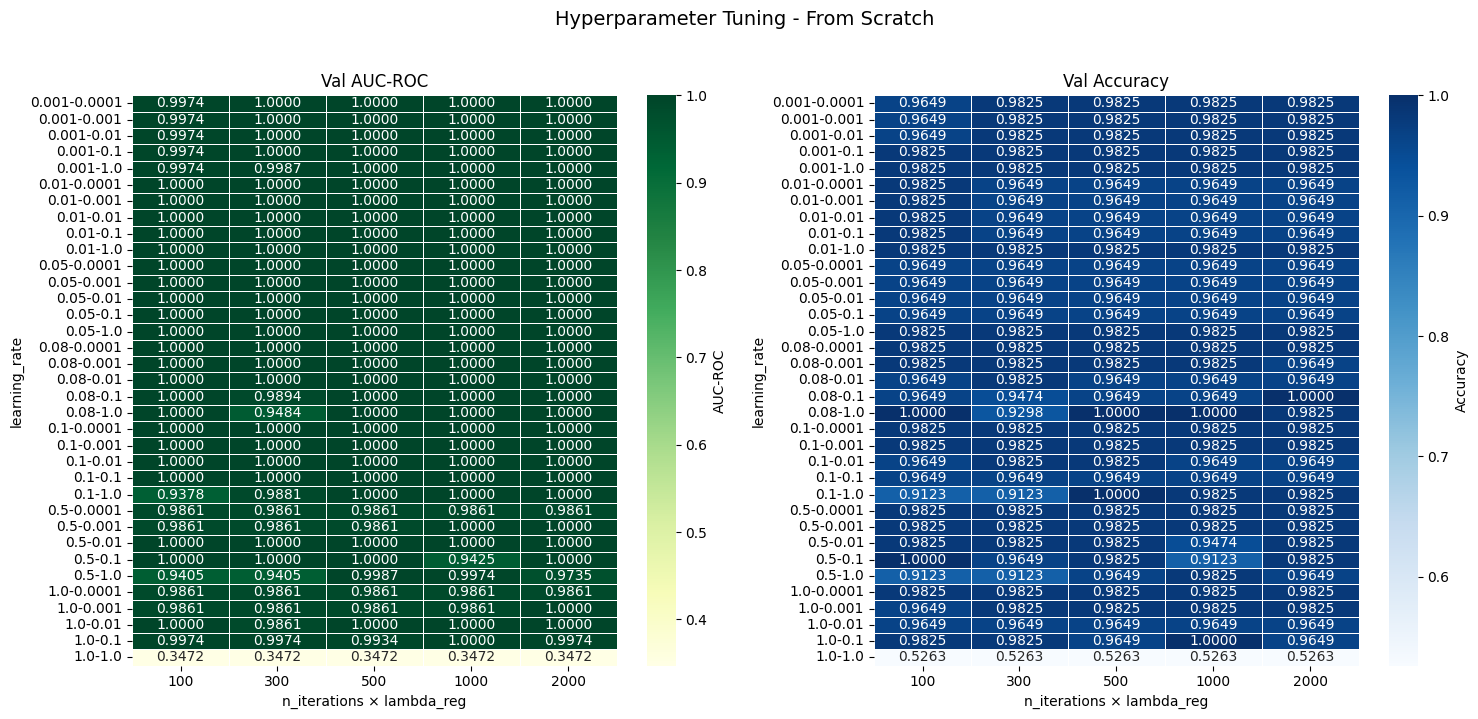

In [23]:
pivot_auc = results_df[results_df['status'] == 'ok'].pivot(
    index=['lr', 'lambda_reg'],
    columns='n_iter',
    values='val_auc'
)
pivot_acc = results_df[results_df['status'] == 'ok'].pivot(
    index=['lr', 'lambda_reg'],
    columns='n_iter',
    values='val_acc'
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

sns.heatmap(
    pivot_auc, annot=True, fmt=".4f", cmap="YlGn",
    linewidths=0.5, ax=ax1, cbar_kws={'label': 'AUC-ROC'}
)
ax1.set_title("Val AUC-ROC", fontsize=12)
ax1.set_xlabel("n_iterations × lambda_reg")
ax1.set_ylabel("learning_rate")

sns.heatmap(
    pivot_acc, annot=True, fmt='.4f', cmap='Blues',
    linewidths=0.5, ax=ax2, cbar_kws={'label': 'Accuracy'}
)
ax2.set_title("Val Accuracy", fontsize=12)
ax2.set_xlabel("n_iterations × lambda_reg")
ax2.set_ylabel("learning_rate")

plt.suptitle("Hyperparameter Tuning - From Scratch", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



**Learning Curve**

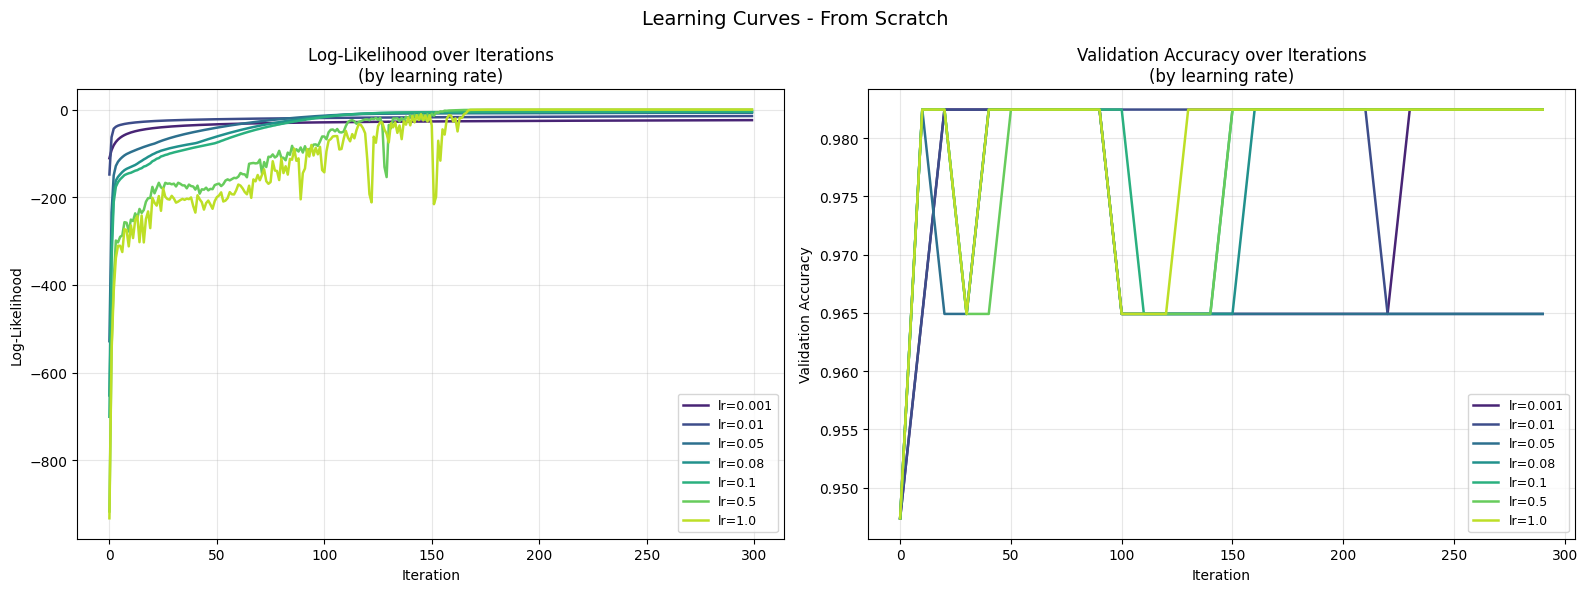

In [24]:
color_cycle = plt.cm.viridis(np.linspace(0.1, 0.9, len(learning_rates)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for lr, color in zip(learning_rates, color_cycle):
    m = LogisticRegressionScratch(learning_rate=lr, n_iterations=300, lambda_reg=0.001)
    m.fit(X_train_b, y_train, X_val=X_val_b, y_val=y_val, checkpoint=10)

    history = m.history

    if not np.any(np.isnan(history)) and not np.any(np.isinf(history)):
        ax1.plot(history, color=color, linewidth=1.8, label=f"lr={lr}")

        steps = list(range(0, 300, 10))

        ax2.plot(steps, m.val_acc_history, color=color, linewidth=1.8, label=f"lr={lr}")
    else:
        ax1.plot([], [], color=color, linewidth=1.8, label=f"lr={lr} (diverged)")

ax1.set_xlabel("Iteration")
ax1.set_ylabel("Log-Likelihood")
ax1.set_title("Log-Likelihood over Iterations\n(by learning rate)", fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.set_xlabel("Iteration")
ax2.set_ylabel("Validation Accuracy")
ax2.set_title("Validation Accuracy over Iterations\n(by learning rate)", fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle("Learning Curves - From Scratch", fontsize=14)
plt.tight_layout()
plt.show()

The comprehensive grid search and the accompanying heatmaps reveal critical dynamics of our custom L2-regularized Logistic Regression model:

- The grid search yields Validation AUC-ROC = 1.0 across multiple configurations - a known characteristic of the Wisconsin dataset given the exceptional linear separability of the **`_worst`** feature group (confirmed in EDA). The L2 penalty ensures this is achieved through a generalizable decision boundary, not memorization.

- Learning rates in $[0.001, 0.1]$ form a robust operating region, stable across $\lambda \in [0.0001, 1.0]$. The critical failure case is **`lr = 1.0`** with strong regularization: the gradient overshoots violently, collapsing Log-Likelihood and dropping AUC to ~0.34.

- The model reaches its global maximum within **200–300 iterations** for optimal learning rates. Extended training (1000–2000 iterations) yields no further improvement, consistent with the theoretical guarantee that $\ell(\theta)$ is globally concave.

A conservative learning rate (**`lr = 0.001`**) with moderate L2 penalty solves this task within 300 iterations. We now proceed to **`scikit-learn`** to explore L1 regularization for automated feature selection.

## **Hyperparameter Tuning - Scikit-learn (Regularization)**

Scikit-learn supports two regularization penalties:

**L2 (Ridge)**

$$\ell_{L2}(\theta) = \ell(\theta) - \frac{\lambda}{2} \sum_{j=1}^{d} \theta_j^2 \qquad \Rightarrow \qquad \frac{\partial \ell_{L2}}{\partial \theta_j} = \frac{\partial \ell}{\partial \theta_j} - \lambda \theta_j$$

**L1 (Lasso)**

$$\ell_{L1}(\theta) = \ell(\theta) - \lambda \sum_{j=1}^{d} |\theta_j| \qquad \Rightarrow \qquad \frac{\partial \ell_{L1}}{\partial \theta_j} = \frac{\partial \ell}{\partial \theta_j} - \lambda \cdot \text{sign}(\theta_j)$$

where $\text{sign}(\theta_j) = +1$ if $\theta_j > 0$, $-1$ if $\theta_j < 0$, and $0$ if $\theta_j = 0$.

Since $|\theta_j|$ is **not differentiable at** $\theta_j = 0$, the gradient is replaced by its **subgradient**. In practice, L1 cannot be optimized efficiently with vanilla gradient descent. For small datasets such as this one, scikit-learn's **liblinear** solver is preferred, it applies a **coordinate descent** algorithm that handles the non-smooth L1 penalty exactly, producing true sparse solutions (i.e., driving irrelevant weights to exactly zero) with faster convergence than stochastic solvers such as **SAGA**.

The regularization strength is controlled by **`C = 1/λ`**: smaller **`C`** applies stronger regularization; larger **`C`** brings the model closer to unregularized. We use **GridSearchCV** with 5-fold stratified cross-validation to select the optimal **`C`** and **`penalty`**.

In [25]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.0, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=SKlearnLR(
        solver='liblinear',
        max_iter=10000,
        random_state=42
    ),
    param_grid=param_grid,
    cv=cv,
    scoring={"auc": "roc_auc", "accuracy": "accuracy"},
    n_jobs = -1,
    verbose=0,
    refit="auc"
)

grid_search.fit(X_train, y_train)

print(f"Best params:")
print(f"{grid_search.best_params_}")
print(f"Best AUC      = {grid_search.best_score_:.4f}")
print(f"Best Accuracy = {grid_search.cv_results_['mean_test_accuracy'][grid_search.best_index_]:.4f}")

Best params:
{'C': 0.1, 'l1_ratio': 1.0}
Best AUC      = 0.9936
Best Accuracy = 0.9774


**Heatmap**

In [26]:
cv_results = pd.DataFrame(grid_search.cv_results_)
print(cv_results.columns)

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_l1_ratio', 'params', 'split0_test_auc',
       'split1_test_auc', 'split2_test_auc', 'split3_test_auc',
       'split4_test_auc', 'mean_test_auc', 'std_test_auc', 'rank_test_auc',
       'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy',
       'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy',
       'std_test_accuracy', 'rank_test_accuracy'],
      dtype='str')


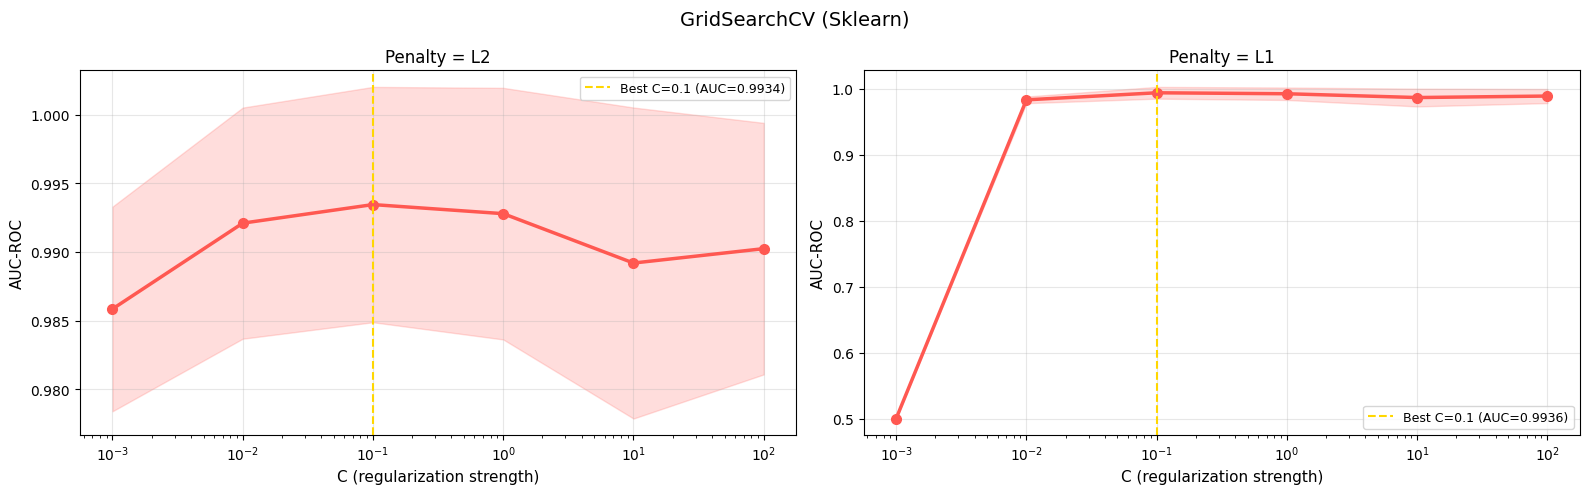

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (l_ratio, label) in zip(axes, [(0.0, 'L2'), (1.0, 'L1')]):
    sub = cv_results[cv_results['param_l1_ratio'] == l_ratio].copy()
    sub['C_val'] = sub['param_C'].astype(float)
    sub = sub.sort_values('C_val')
    ax.plot(
        sub['C_val'], sub['mean_test_auc'], color=COLORS['malignant'],
        linewidth=2.5, marker="o", markersize=7
    )

    ax.fill_between(
        sub['C_val'],
        sub['mean_test_auc'] - sub['std_test_auc'],
        sub['mean_test_auc'] + sub['std_test_auc'],
        alpha=0.2, color=COLORS['malignant'],
    )

    ax.set_xscale('log')
    ax.set_xlabel("C (regularization strength)", fontsize=11)
    ax.set_ylabel("AUC-ROC", fontsize=11)
    ax.set_title(f"Penalty = {label}", fontsize=12)
    ax.grid(alpha=0.3)

    best_c = sub.loc[sub['mean_test_auc'].idxmax(), 'C_val']
    best_score = sub['mean_test_auc'].max()
    ax.axvline(
        best_c, color='gold', linestyle="--", linewidth=1.5,
        label=f"Best C={best_c} (AUC={best_score:.4f})"
    )
    ax.legend(fontsize=9)

plt.suptitle("GridSearchCV (Sklearn)", fontsize=14)
plt.tight_layout()

plt.show()

The automated hyperparameter tuning via **GridSearchCV** successfully validates our prior hypothesis. The optimizer selected **`C = 0.1`** with an **`l1_ratio = 1.0`** (which corresponds to a pure L1 Lasso penalty), achieving an outstanding Validation AUC of **0.9936**. By examining the cross-validation performance plots, several critical insights emerge:

- The L2 confidence band is notably wider than L1's across all values of $C$, reflecting the model's sensitivity to data splits when all 30 correlated features are retained. L1's automatic feature selection eliminates redundant coefficients, producing a substantially more stable estimator.

- L1 peaks at $C = 0.1$, strong enough to suppress multicollinear noise while retaining the dominant predictive signals. L2 is less sensitive to $C$ in this range, consistent with its shrinkage-without-elimination behavior.

- At extreme regularization, L1 drives all coefficients to zero, reducing the model to a trivial classifier (AUC $\approx$ 0.5). The sharp recovery at $C = 10^{-2}$ marks the threshold at which the penalty relaxes sufficiently to isolate the first few dominant features, a behavior unique to L1 and not observed in L2.

**Why did the metric slightly drop compared to the from-scratch model?**

It is crucial to note the slight decrease from our from-scratch model (AUC 1.0 $\rightarrow$ 0.9936). This is not a degradation, but rather a robust reality check. The Sklearn evaluation uses 5-fold Cross-Validation (averaging across 5 splits), whereas the from-scratch model evaluated a single validation split, making it prone to a "lucky" separation. Furthermore, this marginal $0.6\%$ drop in AUC is the necessary mathematical trade-off for achieving Sparsity. L1 deliberately sacrifices minor informational nuances from redundant features to build a vastly simpler, more interpretable, and generalized model.

In [28]:
feature_names_arr = np.array(feature_names)
coef = grid_search.best_estimator_.coef_[0]

nonzero_mask = coef != 0
zero_mask = coef == 0

nonzero_features = pd.Series(
    coef[nonzero_mask], 
    index=feature_names_arr[nonzero_mask]
).sort_values(key=abs, ascending=False)

zero_features    = feature_names_arr[zero_mask]

print(f"Non-zero features ({nonzero_mask.sum()}/{len(coef)}):")
print(nonzero_features.to_string())
print()
print(f"({zero_mask.sum()}/{len(coef)}) features have been eliminated by L1:")
print(", ".join(zero_features))

Non-zero features (6/30):
radius_worst            2.064432
concave points_mean     1.127272
texture_worst           0.702577
concave points_worst    0.416762
symmetry_worst          0.276776
smoothness_worst        0.106136

(24/30) features have been eliminated by L1:
radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se, perimeter_worst, area_worst, compactness_worst, concavity_worst, fractal_dimension_worst


## **Final Model Evaluation (After Tuning)**

In [29]:
# Final model from scratch
if Path(LR_DEFAULT_TUNED_PATH).exists():
    final_scratch = joblib.load(LR_DEFAULT_TUNED_PATH)
else:
    final_scratch = LogisticRegressionScratch(learning_rate=0.001, n_iterations=300, lambda_reg=0.001)
    final_scratch.fit(X_train_b, y_train)
    final_scratch.save(LR_DEFAULT_TUNED_PATH)

scratch_pred_final  = final_scratch.predict(X_test_b)
scratch_proba_final = final_scratch.predict_proba(X_test_b)
scratch_auc_final   = roc_auc_score(y_test, scratch_proba_final)
scratch_acc_final   = accuracy_score(y_test, scratch_pred_final)
scratch_f1_final    = f1_score(y_test, scratch_pred_final)

# Final model
if Path(SKLEARN_TUNED_PATH).exists():
    final_sklearn = joblib.load(SKLEARN_TUNED_PATH)
else:
    final_sklearn = grid_search.best_estimator_
    joblib.dump(final_sklearn, SKLEARN_TUNED_PATH)

sk_pred_final  = final_sklearn.predict(X_test)
sk_proba_final = final_sklearn.predict_proba(X_test)[:, 1]
sk_auc_final   = roc_auc_score(y_test, sk_proba_final)
sk_acc_final   = accuracy_score(y_test, sk_pred_final)
sk_f1_final    = f1_score(y_test, sk_pred_final)

print()
print("=" * 70)
print(f"  {'Model':<30} {'Acc':>8} {'AUC':>8} {'F1':>8}")
print("-" * 70)
print(f"  {'From Scratch (tuned)':<30} {scratch_acc_final*100:>7.2f}% {scratch_auc_final:>8.4f} {scratch_f1_final:>8.4f}")
print(f"  {'Sklearn (GridSearchCV)':<30} {sk_acc_final*100:>7.2f}% {sk_auc_final:>8.4f} {sk_f1_final:>8.4f}")
print("=" * 70)
print()
print(f"  Best From Scratch params : lr={best_lr}, n_iter={best_n_iter}, lambda={best_lamda}")
print(f"  Best Sklearn params      : {grid_search.best_params_}")



  Model                               Acc      AUC       F1
----------------------------------------------------------------------
  From Scratch (tuned)             97.37%   0.9967   0.9639
  Sklearn (GridSearchCV)           98.25%   0.9974   0.9756

  Best From Scratch params : lr=0.001, n_iter=300, lambda=0.001
  Best Sklearn params      : {'C': 0.1, 'l1_ratio': 1.0}


**Confusion Matrix**

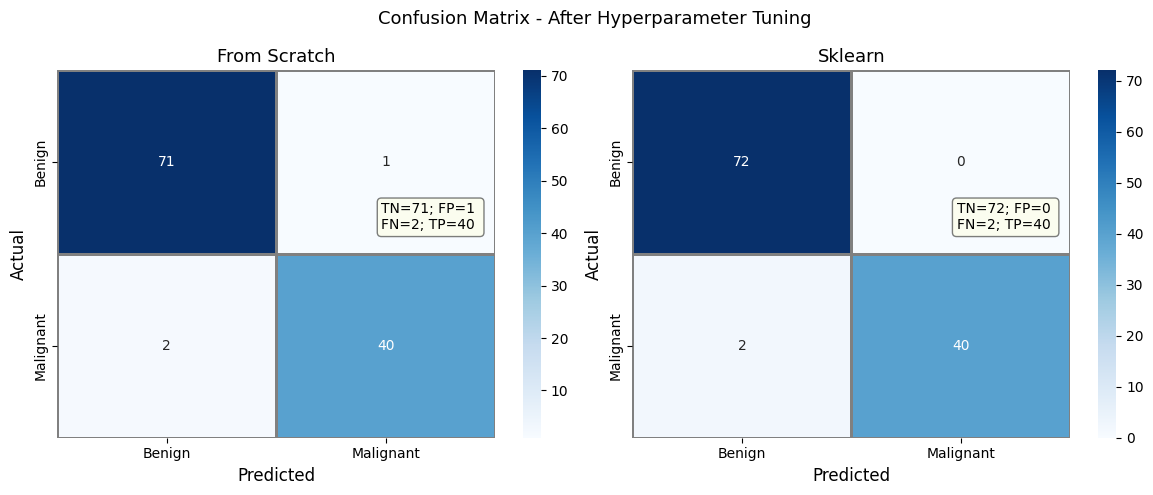

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_confusion_matrix(y_test, scratch_pred_final, title="From Scratch", ax=axes[0])
plot_confusion_matrix(y_test, sk_pred_final, title="Sklearn", ax=axes[1])
plt.suptitle("Confusion Matrix - After Hyperparameter Tuning", fontsize=13)
plt.tight_layout()

plt.show()

**ROC Curve**

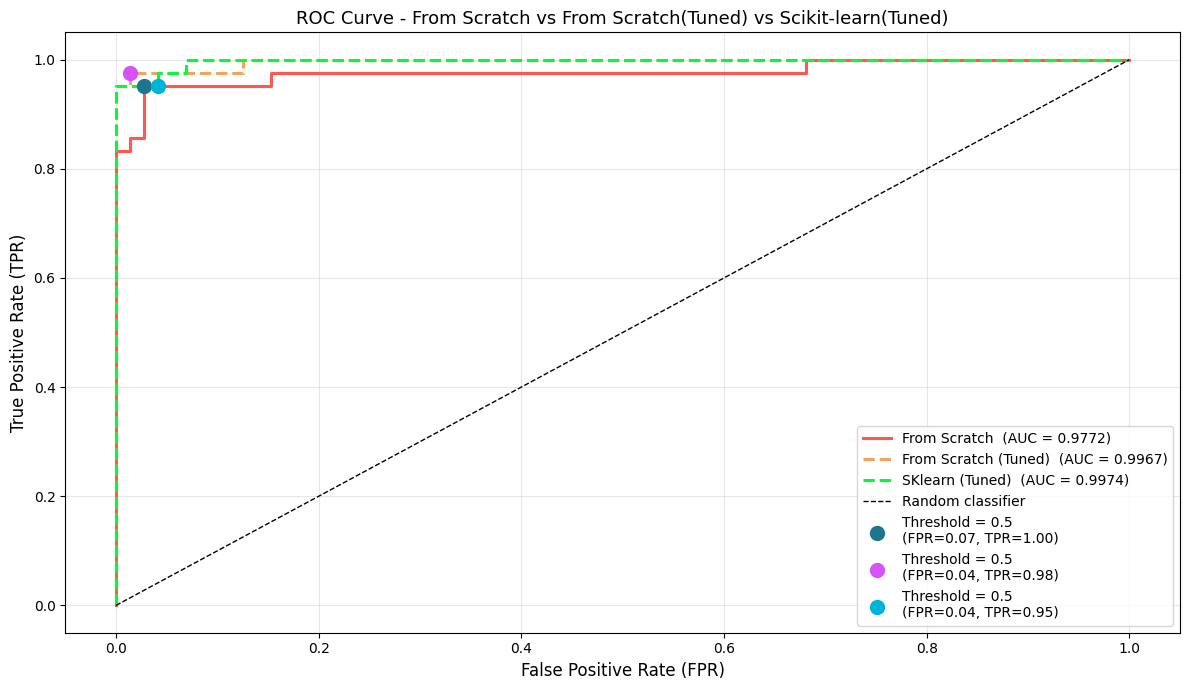

In [39]:
fig = plot_roc_curve(
    models=[
        {'name': 'From Scratch', 'y_proba': y_proba_test, 'color': COLORS['malignant'], 'color_threshold': COLORS['dark_gray']},
        {'name': 'From Scratch (Tuned)', 'y_proba': scratch_proba_final, 'color': COLORS['orange'], 'color_threshold': COLORS['purple'], 'linestyle': '--'},
        {'name' : 'SKlearn (Tuned)', 'y_proba': sk_proba_final, 'color': COLORS['green'], 'color_threshold': COLORS['teal'], 'linestyle': '--'}
    ],
    y_true=y_test,
    title="ROC Curve - From Scratch vs From Scratch(Tuned) vs Scikit-learn(Tuned)"
)
plt.show()

## **Conclusion**

The final model (Sklearn with L1 Penalty, **`C=0.1`**) successfully resolves the initial medical objective by addressing multicollinearity and reducing the feature space from 30 to just 6 core predictors. Achieving an outstanding AUC of 0.9974, alongside a near-zero False Positive Rate (FPR) and high True Positive Rate (TPR), the model demonstrates both predictive excellence and robust stability. By prioritizing sparsity, we transformed a complex dataset into a streamlined, highly interpretable diagnostic tool that fully meets the rigorous standards for clinical decision support.